In [1]:
import numpy as np
from scipy.special import iv
from scipy.integrate import quad
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings("ignore")  

rng = np.random.default_rng(seed=0)

*In this notebook, we introduce the problem of standard Monte Carlo, and generalize it to overcome the problem introduced*

# The Problem

There are two ways to make a distribution difficult to sample from. The first way is for the distribution to be very heavy tailed. Important tail events are rare enough to be poorly captured by na&iuml;ve monte carlo, but common enough that they should affect our decision making in a meaningful way. The second way is when the distribution we want to sample from is just so bizzare that we have no idea how to sample from it. We consider the first scenario first. It is quite common, especially in simple statistical applications. 

We consider a different setting. Suppose we have an experiment modeled by a poisson distribution, whose parameter is controlled by some prior with heavy tails. For concreteness, suppose that the poisson distribution is modeling the number of extreme insurance claims, and our parameter must be heavy-tailed to reflect heavy-tailedness in the real world. A natural way to implement this is to choose our parameter's prior $\theta$ to be Cauchy distributed. Since the cauchy distribution is all reals, our insurance process should have parameter $e^{\theta}$ or $|\theta|$, but for simplicty, and to emphasize rare scenarios, $e^\theta$ is what we will use. Thus, we have:
$$
Y \sim \mathrm{Poi}(e^{\theta}) \qquad \theta \sim \mathrm{Cauchy}(0,1)
$$
Suppose that the insurance company insuring claims will go insolvent if $\theta$ is really high. The interpretation here is that the insurance company will face operating expenses in this particular climate (described by $\theta$) that are too expensive, and will not survive. Suppose the threshold is $\tau$. We are interested in estimating the indicator random variable $[\theta > \tau]$ ([Iverson Brackets](https://en.wikipedia.org/wiki/Iverson_bracket)). So, using the standard quadratic loss, we have the loss:
$$
L(\theta, \delta) = ([\theta > \tau] - \delta)^2
$$
whose minimizer is the conditional expectation of $[\theta > \tau]$, i.e. 
$$
\delta(Y) = \Pr(\theta > \tau | Y)
$$
As we will see, both analytical techniques and (basic) monte carlo techniques fail. Let's try analytical techniques first. 
Let's derive the posterior distribution of $\theta$. 
$$
p(\theta|Y) = \frac{p(Y | \theta) p(\theta)}{\int_{-\infty}^\infty p(Y | \theta) p(\theta) d \theta} = \frac{\frac1{\pi(1 + \theta^2)} e^{- ne^\theta + \theta \sum_{i=1}^n Y_i }}{\int_{-\infty}^\infty 
e^{- n e^\theta + \theta \sum_{i = 1}^n Y_i} \frac1{\pi(1 + \theta^2)} d\theta
}
$$
So we are aiming to calculate:
$$
\Pr(\theta > \tau | Y) = \frac{\int_{\tau}^\infty 
e^{- n e^\theta + \theta \sum_{i = 1}^n Y_i} \frac1{\pi(1 + \theta^2)} d\theta}{\int_{-\infty}^\infty 
e^{- n e^\theta + \theta \sum_{i = 1}^n Y_i} \frac1{\pi(1 + \theta^2)} d\theta}
$$
Already, we can see where the problems in this calculation come in. $e^{-n e^\theta}$ will very quickly go to zero, but to show that analytic techniques are problematic here, let's just try them out!

In [47]:
def sample_cauchy_data(tau=7, N=50):
    theta = rng.standard_cauchy()
    lam = np.clip(np.exp(np.clip(theta, -700, 700)), 1e-10, 1e10)
    Y = rng.poisson(lam=lam, size=N)
    return {"theta": theta, "Y": Y, "p": float(theta > tau)}

def run_sims_cauchy(method, num_sim=100, tau=7, N=50, M=1000, Y=None, p_true=None):
    results = np.zeros((num_sim, 2), dtype=float)
    for i in range(num_sim):
        res = method(Y=Y, tau=tau, N=N, M=M, p_true=p_true)
        true_i = res["p"] if p_true is None else p_true
        results[i] = [true_i, res["p_hat"]]
    return results

def sum_res_cauchy(results, method_name="Bayes Estimator"):
    est = results[:, 1]
    true = results[:, 0].astype(int)
    numeric = np.isfinite(est)

    print(f"Total simulations: {len(results)}")
    print(f"Numeric rate: {100*np.mean(numeric):.1f}%")
    print(f"Non-numeric rate: {100*np.mean(~numeric):.1f}%")
    print(f"    theta > tau  : {100*np.mean(~numeric & (true == 1))/np.mean(true == 1):.1f}%")
    print(f"    theta <= tau : {100*np.mean(~numeric & (true == 0))/np.mean(true == 0):.1f}%")
    print(f"Overall prevalence P(theta > tau): {np.mean(true):.3f}")

    e = est[numeric]
    t = true[numeric]
    print(f"Numeric-only prevalence: {np.mean(t):.3f}")
    print(f"MSE: {np.mean((e - t) ** 2):.4f}")
    print(f"MAE: {np.mean(np.abs(e - t)):.4f}")

    plt.figure(figsize=(10, 5))
    x = t + np.random.normal(0, 0.02, size=len(t))
    plt.scatter(x, e, alpha=0.6)
    plt.axhline(0, color="gray", linestyle="--", alpha=0.3)
    plt.axhline(1, color="gray", linestyle="--", alpha=0.3)
    plt.xticks([0, 1])
    plt.ylim(-0.1, 1.1)
    plt.xlabel("True value (0 or 1)")
    plt.ylabel("Estimated probability")
    plt.title(method_name)
    plt.grid(True, alpha=0.3)
    plt.show()
    plt.clf()

In [51]:
def num_est_sim_cauchy(Y=None, tau=6, N=50, M=None, p_true=None):
    if Y is None:
        theta = rng.standard_cauchy()
        lam = np.clip(np.exp(theta), 1e-10, 1e10)
        Y = rng.poisson(lam=lam, size=N)
        p_true = float(theta > tau)
    else:
        Y = np.asarray(Y)
        N = len(Y)

    S = np.sum(Y)

    def integrand(t):
        exp_factor = np.exp(-N * np.exp(t) + S * t)
        coeff = np.pi * (1 + t ** 2)
        return exp_factor / coeff

    num, _ = quad(integrand, tau, np.inf)
    denom, _ = quad(integrand, -np.inf, np.inf)
    p_hat = np.clip(num / denom, 0, 1)
    return {"p": p_true, "p_hat": p_hat}

Total simulations: 1000
Numeric rate: 94.2%
Non-numeric rate: 5.8%
    theta > tau  : 100.0%
    theta <= tau : 1.4%
Overall prevalence P(theta > tau): 0.045
Numeric-only prevalence: 0.000
MSE: 0.0000
MAE: 0.0000


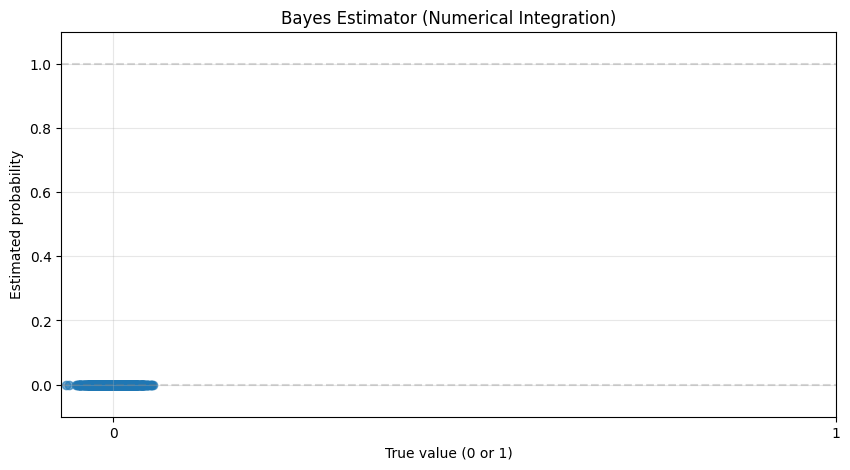

<Figure size 640x480 with 0 Axes>

In [53]:
sum_res_cauchy(run_sims_cauchy(method=num_est_sim_cauchy, num_sim=1000), method_name = "Bayes Estimator (Numerical Integration)")

If we get a typical value of $\theta$, our estimator is great! But as soon as we get one of the cases we care about, we have a completely numerically unstable solution, with a NaN rate of 100%! 6.2% is rare, but not that rare, and we aren't estimating any of that! Bad! However, maybe the failure of the analytical estimator is just due to the fact that we are being lazy. There are a lot of numerical stability tricks out there that can maybe fix this problem. Here is an outline of some of the tricks used. 
* `np.clip(theta, -700, 700)` prevents overflow to `inf` and silent underflow to `0`. 
* `np.clip` for `lam`, again prevents overflow to `inf` and silent underflow to `0`. 
* $\mathrm{LogSumExp}$ trick for integration. Attempting to integrate $\exp(f(x))$ for $f(x)$ that has high variance will be quite numerically difficult. In [statistical learning](https://gregorygundersen.com/blog/2020/02/09/log-sum-exp/), we often convert scores $z_i$ to probabilities via 
$$
\mathrm{SoftMax}(z) = \left(\frac{e^{z_i}}{\sum_{i = 1}^n e^{z_i}}\right)_{i = 1}^n
$$
obviously, when $z_i$ is large, we can face very annoying numerical instability problems. To fix this, we consider 
$$
\mathrm{LogSumExp}(z) = \mathrm{LSE}(z) := \log{\sum_{i = 1}^n e^{z_i}}
$$
Then, we consider $c = \max_i z_i$ and factor this out from each of the summands. This will ensure that each summand is between $1$ and $e$. We get:
$$
\mathrm{LSE}(z) = c + \log{\sum_{i = 1}^n e^{z_i - c}}
$$
which is much more numerically stable. We can naturally apply a similar trick to our integration problem. Let $c = \max_x f(x)$. Then our poorly behaved integral is given by:
$$
e^c \int \exp(f(x) - c)
$$
which is much easier to compute with floating point arithmetic. To implement this trick, we represent the integrand in exponential form, i.e. we have the following integrand:
$$
\exp\left(- n e^{\theta} + \theta \sum_{i = 1}^n Y_i - \log{\pi} - \log{(1 + \theta^2)}\right)
$$
* `np.log1p` trick. When $t$ is very small, $\log{1 + t} \approx t$. However, with floating point arithmetic, small $t$ will result in `1 + t == 1`, and `log(1 + t) == 0.0`. This is bad, so fortunately numpy implements a function `np.log1p` that returns `t` for small `t`. This is important for $\log{(1 + \theta^2)}$
* `window`. Integrating over a finite window gives a better chance that quadrature will integrate the tiny peak accurately. 

In [54]:
def num_est_sim_cauchy(Y=None, tau=6, N=50, M = None, p_true = None):
    if Y is None:
        data = sample_cauchy_data(tau=tau, N=N)
        Y = data["Y"]
        p_true = data["p"]
    else:
        Y = np.asarray(Y)
        N = len(Y)

    S = np.sum(Y)

    def log_kernel(t):
        # Unnormalized log posterior kernel (without normalizing constant).
        exp_t = np.exp(np.clip(t, -700, 700))
        return -N * exp_t + S * t - (np.log(np.pi) + np.log1p(t * t))

    # Approximate posterior mode for Poisson log-link model.
    t_mode = np.log(max(S, 1e-12) / N) if S > 0 else -20.0
    c = log_kernel(t_mode)

    def scaled_integrand(t):
        lk = log_kernel(t)
        z = lk - c
        return float(np.exp(z))

    # Finite window around the mode
    window = 40.0
    lo = t_mode - window
    hi = t_mode + window

    denom, _ = quad(scaled_integrand, lo, hi)

    num_lo = max(tau, lo)
    if num_lo >= hi:
        num = 0.0
    else:
        num, _ = quad(scaled_integrand, num_lo, hi)

    p_hat = np.clip(np.float64(num) / np.float64(denom), 0, 1)
    return {"p": p_true, "p_hat": p_hat}

Total simulations: 1000
Numeric rate: 96.0%
Non-numeric rate: 4.0%
    theta > tau  : 85.1%
    theta <= tau : 0.0%
Overall prevalence P(theta > tau): 0.047
Numeric-only prevalence: 0.007
MSE: 0.0052
MAE: 0.0052


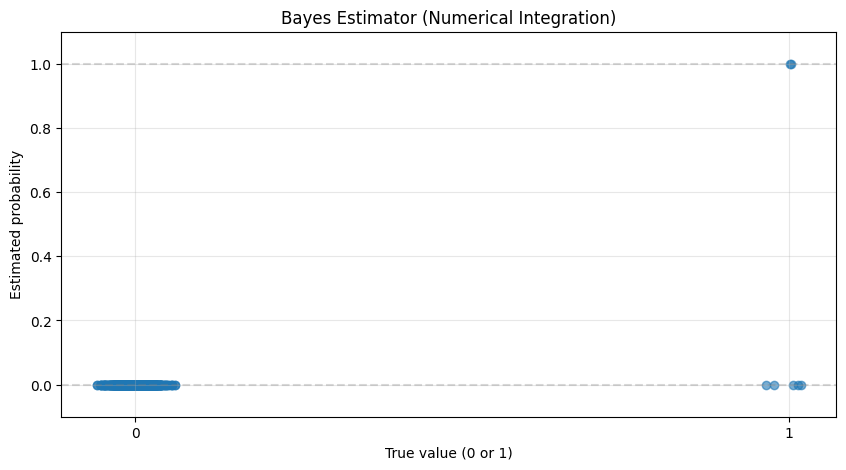

<Figure size 640x480 with 0 Axes>

In [55]:
sum_res_cauchy(run_sims_cauchy(method=num_est_sim_cauchy, num_sim=1000), method_name = "Bayes Estimator (Numerical Integration)")

This is better! But it's still quite poor. We still get a NaN rate of 85.1% when we actually experience default. It's clear that no matter how clever we are with our approach, this won't work. 

# Monte Carlo
As a quick aside, imagine how frustrating this was for people first thinking about this stuff! Putting so much work into this technique, just for it to be the wrong approach. This is unfortunately what research is like. Try your best with your current approach, and if it still doesn't work you have to try something completely new. Let's see how our monte carlo estimator fares. 

We are estimating the following conditional probability:
$$
\Pr(\theta > \tau | Y) = \frac{\int_{\tau}^\infty 
e^{- n e^\theta + \theta \sum_{i = 1}^n Y_i} \frac1{\pi(1 + \theta^2)} d\theta}{\int_{-\infty}^\infty 
e^{- n e^\theta + \theta \sum_{i = 1}^n Y_i} \frac1{\pi(1 + \theta^2)} d\theta}
$$
For our na&iuml;ve monte carlo estimator, we estimate $\theta_j \sim \mathrm{Cauchy}(0,1)$, and compute: 
$$
\hat{\delta}(Y) = \frac{\sum_{j = 1}^M [\theta > \tau] e^{- n e^{\theta} + \theta\sum_{i = 1}^n Y_i}}{\sum_{j = 1}^Me^{- n e^{\theta} + \theta\sum_{i = 1}^n Y_i}}
$$
This will naturally converge to our desired function as $M$ tends to $\infty$. Let's see how it works! Let's also implement the $\mathrm{LogSumExp}$ trick as well. 

In [58]:
def mc_est_sim_cauchy(Y=None, tau=7, N=50, M=1000, p_true=None):
    if Y is None:
        data = sample_cauchy_data(tau=tau, N=N)
        Y = data["Y"]
        p_true = data["p"]
    else:
        Y = np.asarray(Y)
        N = len(Y)

    S = np.sum(Y)
    t_samples = rng.standard_cauchy(size=M)
    log_factor = -N * np.exp(np.clip(t_samples, -700, 700)) + S * t_samples
    c = np.max(log_factor)
    exp_factor = np.exp(log_factor - c)
    p_hat = np.mean(exp_factor * (t_samples > tau)) / np.mean(exp_factor)
    p_hat = np.clip(p_hat, 0, 1)
    return {"p": p_true, "p_hat": p_hat}

Total simulations: 10000
Numeric rate: 100.0%
Non-numeric rate: 0.0%
    theta > tau  : 0.0%
    theta <= tau : 0.0%
Overall prevalence P(theta > tau): 0.044
Numeric-only prevalence: 0.044
MSE: 0.0006
MAE: 0.0006


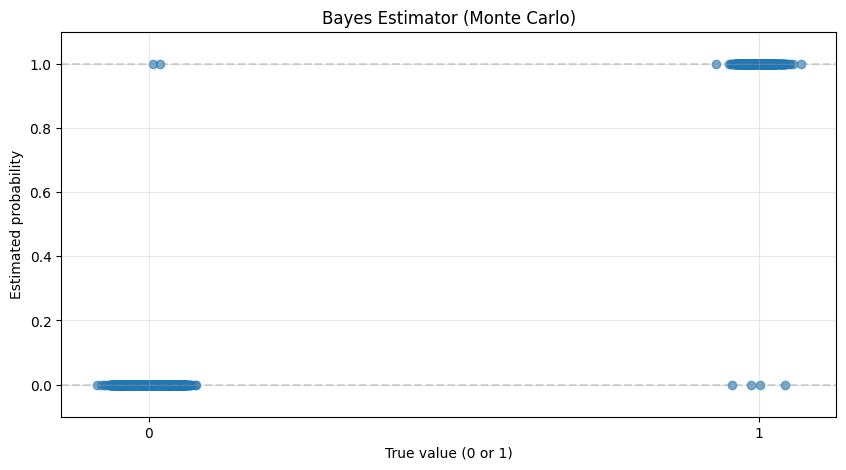

<Figure size 640x480 with 0 Axes>

In [59]:
sum_res_cauchy(run_sims_cauchy(method=mc_est_sim_cauchy, num_sim=10000), method_name = "Bayes Estimator (Monte Carlo)")

This looks great! But looks can be deceiving. Let's investigate what the *variance* of our estimator looks like.  

In [70]:
def plot_var_cauchy(method, tau=7, N=50, Ms=np.logspace(1, 4, num=40, dtype=int), num_rep=500, Y=None):
    if Y is None:
        Y = rng.poisson(lam=np.exp(np.clip(tau, -20, 20)), size=N)

    variances = []
    for M in Ms:
        ests = [method(Y=Y, tau=tau, N=N, M=M)["p_hat"] for _ in range(num_rep)]
        variances.append(np.var(ests))

    plt.figure(figsize=(10, 5))
    plt.plot(Ms, variances, marker='o')
    plt.xscale('log')
    plt.xlabel('Number of Monte Carlo Samples (M)')
    plt.ylabel('Variance of Estimator')
    plt.title(r'Conditional Variance $\mathrm{Var}(\hat{p} | Y)$ for standard Monte Carlo')
    plt.grid(True, alpha=0.3)
    plt.show()
    plt.clf()

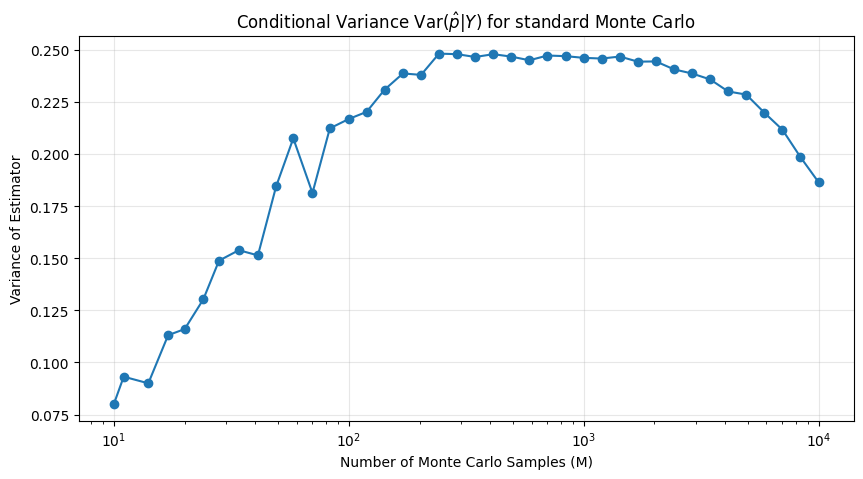

<Figure size 640x480 with 0 Axes>

In [71]:
plot_var_cauchy(mc_est_sim_cauchy)

Our variance doesn't decrease! This isn't good. We need the variance of the monte carlo estimator to decrease as the fidelity of the monte carlo estimate increases. Why doesn't our variance decrease? The reason for this comes down to the peakedness of our likelihood. Let's look what our log-likelihood looks like.  

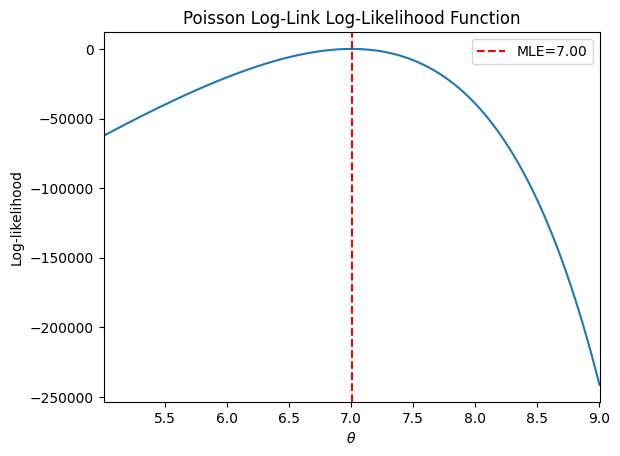

In [62]:
# Parameters: n = sample size, S = sum of observations
n, S = 50, 55000 
mle = np.log(S / n)
theta = np.linspace(mle - 2, mle + 2, 50000)

# Log-likelihood: l(theta) = -n*exp(theta) + S*theta
log_lik = -n * np.exp(theta) + S * theta
log_lik -= np.max(log_lik)  # For numerical stability in plotting

plt.plot(theta, log_lik)
plt.axvline(mle, color='r', linestyle='--', label=f'MLE={mle:.2f}')
plt.xlim(mle - 2, mle + 2)
plt.title("Poisson Log-Link Log-Likelihood Function")
plt.xlabel(r"$\theta$")
plt.ylabel("Log-likelihood")
plt.legend()
plt.show()

As is clear from the log-likelihood, the gradient of the log-likelihood w.r.t $\theta$ is massive. Once we pick $c$, essentially all the other samples are set to 0. In other words, if $f(\theta) = - n e^{\theta} + \theta \sum Y_i$, then 
$$
\exp(f(\theta) - c) \approx [\theta = \arg\max_t f(t)]
$$
Our estimator then just boils down to 
$$
\hat{\delta} = [\arg\max_t f(t) > \tau]
$$
which is a valid estimator, but has an effective sample size of 1! This is precisely why our variance doesn't decrease as we increase $M$. We do not have a valid estimator, since we need the variance to decrease as we take $M$ larger and larger. 

Let's investigate further Monte Carlo techniques. 

## Importance Sampling
Let's give a formal defintion for our Monte Carlo setup, as was introduced by Metropolis, Ulam, and Von Neumann. We are interested in computing an integral over $\theta$:
$$
\int g(\theta) f(x | \theta) \pi(\theta) d \theta
$$
where $f$ is our likelihood function. If we can sample from $\pi(\theta)$ we can approximate this integral with
$$
\frac1{M} \sum_{i = 1}^{M} g(\theta_i) f(x | \theta_i)
$$
and similarly, if we can sample from the density proportional to $f(x|\theta)\pi(\theta)$, then the integral we approximate is a little different 
$$
\frac1{M} \sum_{i = 1}^{M} g(\theta_i) \to \frac{\int g(\theta) f(x|\theta) \pi(\theta) d\theta}{\int f(x|\theta) \pi(\theta) d \theta}
$$
However, as we saw above, this setup can run into some problems. To solve this, Importance Sampling was introduced to statistics in 1978 by Teun Kloek and Herman K. van Dijk. Note that we can write the above integral in an equivalent form: 
$$
\int g(\theta) \frac{f(x | \theta)\pi(\theta)}{h(\theta)} h(\theta) d\theta
$$
From this, we can see that if $h$ is a density, then we can sample from $h(\theta)$, and our natural estimator is given by:
$$
\frac1{M} \sum_{i = 1}^M g(\theta_i) \omega(\theta_i)
$$
where 
$$
\omega(\theta) = \frac{f(x | \theta) \pi(\theta)}{h(\theta)}
$$
and similarly, an approximation to $\mathbb{E}[g(\theta)|x]$ is given by:
$$
\frac{\sum_{i = 1}^M g(\theta_i)\omega(\theta_i)}{\sum_{i = 1}^M \omega(\theta_i)}
$$
Naturally, there are some restrictions on $h$, namely, we don't want to be dividing by zero, so we want to make sure that the support of $h$ is contained in the support of $f(x| \theta) \pi(\theta)$. As we have seen before, we want to make sure that we don't run into the problem where we get a couple of very large $\omega(\theta_i)$ and the rest are inconsequential. The variance of estimator would be non-decreasing. 

There are many generic choices of an importance function. Here is a list:
* $\pi(\theta)$ - Prior
* $p(\theta | x)$ - Posterior
* $\ell(\theta | x)$ - likelihood

Recall, we have:
\begin{align*}
\pi(\theta) &= \frac1{\pi(1 + \theta^2)}\\
p(\theta | x) &\propto \frac{e^{-n e^{\theta} + \theta \sum Y_i}}{1 + \theta^2}\\
\ell(\theta | x) &= e^{-n e^{\theta} + \theta \sum Y_i}
\end{align*}
The first one we already tried, and it didn't work, the second, I have no idea how to sample from, but the third seems fairly tractable. Notice that we can do a little $u = e^{\theta}$ substitution. $u^{-1}(u) = \log(u)$ so we get an inverse jacobian of $\frac1{u}$. Our original candidate density was:
$$
h(\theta) = e^{-e^{\theta} + \theta \cdot x}
$$
The density of $u$ is given by:
$$
g(u) \propto e^{- u + x\log(u)} u^{-1} = u^{x - 1} e^{-u}
$$
which shows that $u \sim \Gamma(x, 1)$. With our full sample, $Y$, we have
$$
u \sim \Gamma \left(\sum_{i = 1}^n Y_i, n\right)
$$
in the shape, rate parameterization. So, our scheme is to sample $u$ from this gamma distribution, and then let $\theta = \log(u)$. 

Our Importance Sampling scheme, once we have $\theta$ as above, is as follows:
$$
\hat{\delta}(Y) = \frac{\sum_{j = 1}^M [\theta_j > \tau] (1 + \theta_j^2)^{-1}}{\sum_{j = 1}^M (1 + \theta_j^2)^{-1}}
$$

There is one important thing to note. If $Y_i \equiv 0$, then we cannot sample from $u$. We have a degenerate distribution. We have a very simple density for the posterior though. 
$$
p\left(\theta \bigg| \sum_{i = 0}^n Y_i = 0\right) \propto \frac{e^{- n e^{\theta}}}{1 + \theta^2}
$$
We can thus just sample from the cauchy distribution to get our estimator. Namely:
$$
\hat{\delta}(Y) = \frac{\sum_{j = 1}^M [\theta_j > \tau] e^{-ne^{\theta_j}}}{\sum_{j = 1}^M e^{-n e^{\theta_j}}}
$$
Again, we implement the $\mathrm{LogSumExp}$ trick. 

In [67]:
def is_est_sim_cauchy(Y=None, tau=7, N=50, M=1000, p_true = None):
    if Y is None:
        data = sample_cauchy_data(tau=tau, N=N)
        Y = data["Y"]
        p_true = data["p"]
    else:
        Y = np.asarray(Y)
        N = len(Y)

    S = np.sum(Y)
    if S == 0:
        # Degenerate gamma proposal case; fall back to Cauchy samples with stabilized weights.
        t_samples = rng.standard_cauchy(size=M)
        log_w = -N * np.exp(np.clip(t_samples, -700, 700))
        max_log_w = np.max(log_w)
        w = np.exp(log_w - max_log_w)
        p_hat = np.sum((t_samples > tau) * w) / np.sum(w)
        return {"p": p_true, "p_hat": p_hat}

    u = rng.gamma(shape=S, scale=1.0 / N, size=M)
    t_samples = np.log(u)
    coef = (1 + t_samples ** 2) ** (-1)
    p_hat = np.mean(coef * (t_samples > tau)) / np.mean(coef)
    p_hat = np.clip(p_hat, 0, 1)
    return {"p": p_true, "p_hat": p_hat}

Total simulations: 1000
Numeric rate: 100.0%
Non-numeric rate: 0.0%
    theta > tau  : 0.0%
    theta <= tau : 0.0%
Overall prevalence P(theta > tau): 0.045
Numeric-only prevalence: 0.045
MSE: 0.0000
MAE: 0.0000


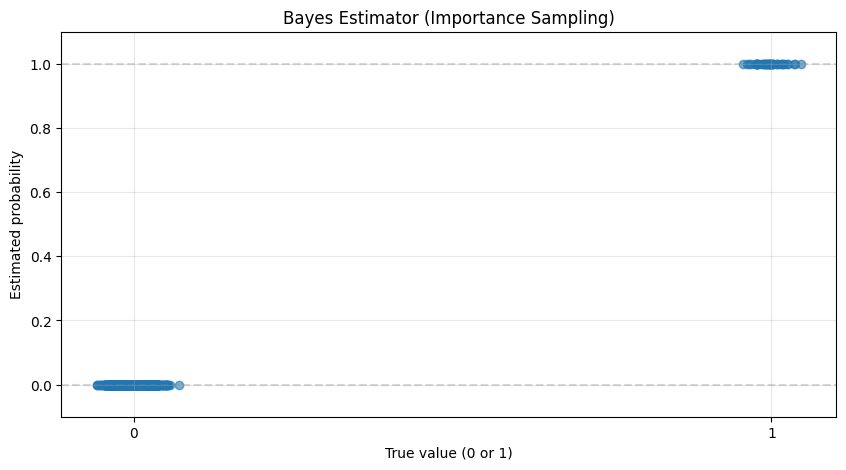

<Figure size 640x480 with 0 Axes>

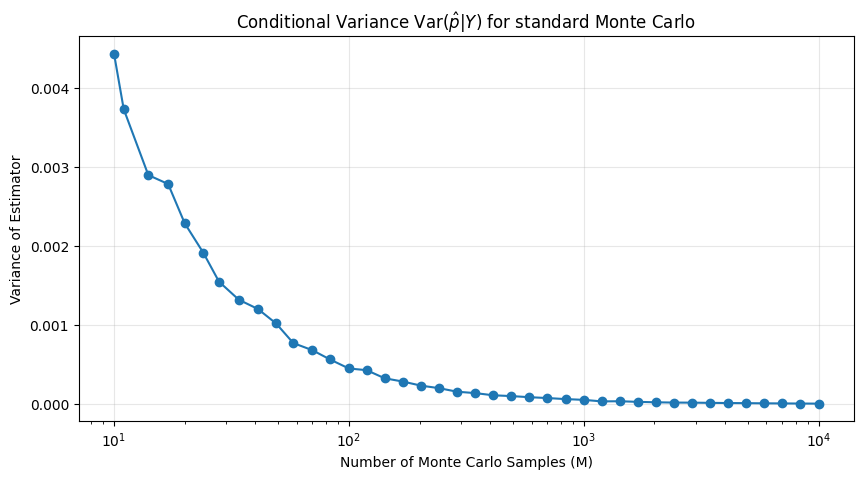

<Figure size 640x480 with 0 Axes>

In [74]:
sum_res_cauchy(run_sims_cauchy(method=is_est_sim_cauchy, num_sim=1000), method_name = "Bayes Estimator (Importance Sampling)")
plot_var_cauchy(is_est_sim_cauchy)

And we can see that importance sampling works, and works great. However, this is not a super abstract method. We lucked out that our model had a nice importance function, and, in general, choosing a nice importance function is much more of an art than a skill (however in our case, we benefited from finding an importance function that is an [exponential family](https://en.wikipedia.org/wiki/Exponential_family)-some exponential families have very nice sampling properties). We really should look for more abstract methods of sampling that don't rely on the experience of the statistician. The very first method that people came up with, even before importance sampling was introduced, is Rejection Sampling, and is one of the most natural ways to sample for Monte-Carlo.